<a href="https://colab.research.google.com/github/EgorMatveev26/MO_Attack/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 4. Математика CNN и FGSM-атаки

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам Лекции 3**

**Формат:** индивидуально

**Среда:** Python, PyTorch, torchvision

## Цель работы
Закрепить математический аппарат свёртки и рецептивного поля, а также научиться конструировать и анализировать evasion-атаку методом Fast Gradient Sign Method (FGSM) на реальной свёрточной сети.

## Результаты обучения
После выполнения работы вы должны уметь:
- рассчитывать размер выходной карты признаков и рецептивное поле для произвольной конфигурации свёрточных слоёв;
- объяснять архитектурные решения LeNet, AlexNet, VGG, ResNet и их мотивацию;
- реализовывать FGSM-атаку по формуле $ x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)) $;
- строить и интерпретировать зависимость Attack Success Rate от бюджета $\epsilon$;
- применять adversarial training как базовую меру защиты.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [ ]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, matplotlib, torch, torch.nn, torch.nn.functional, torchvision

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # TODO: определите device (cuda, если доступна, иначе cpu)
device


device(type='cpu')

## Часть I. Математика CNN

### 1.1. Расчёт размера feature map

**Задание:** реализуйте функцию расчёта размера выходной карты признаков по формуле

$ H_{out} = \left\lfloor \frac{H - k + 2p}{s} \right\rfloor + 1 $

и рассчитайте её для заданных конфигураций.

In [ ]:
# TODO: реализуйте функцию
# p-паддинг(для того чтобы сохранить полную карту признаков после свертки), k-размер ядра, s-шаг, H-размер входа
def conv_output_size(H, k, s, p):
    return (H - k + 2 * p) // s + 1

# Рассчитайте H_out для следующих конфигураций и заполните таблицу результатов
configs = [
    {"H": 224, "k": 7, "s": 2, "p": 3},
    {"H": 224, "k": 3, "s": 1, "p": 1},
    {"H": 56,  "k": 3, "s": 2, "p": 1},
    {"H": 28,  "k": 5, "s": 1, "p": 0},
]

# TODO: примените conv_output_size ко всем конфигурациям и выведите результат(размер выходной карты признаков по высоте после свертки)
for c in configs:
    out = conv_output_size(c["H"], c["k"], c["s"], c["p"])
    print(f"H={c['H']}, k={c['k']}, s={c['s']}, p={c['p']}  ->  H_out={out}")


H=224, k=7, s=2, p=3  ->  H_out=112
H=224, k=3, s=1, p=1  ->  H_out=224
H=56, k=3, s=2, p=1  ->  H_out=28
H=28, k=5, s=1, p=0  ->  H_out=24


### 1.2. Рецептивное поле

**Задание:** реализуйте функцию расчёта рецептивного поля по рекуррентной формуле

$ RF_L = RF_{L-1} + (k_L - 1)\prod_{i=1}^{L-1} s_i $

и сравните рецептивное поле для двух архитектурных решений с одинаковым итоговым покрытием, но разным числом параметров (в духе аргумента VGG о малых ядрах).

In [ ]:
# TODO: реализуйте функцию
def receptive_field(layers):
    # layers — список пар (kernel_size, stride)
    rf = 1
    stride_prod = 1
    for k, s in layers:
        rf = rf + (k - 1) * stride_prod
        stride_prod *= s
    return rf

# Вариант А: три слоя 3x3 (stride=1)
layers_a = [(3, 1), (3, 1), (3, 1)]
# Вариант Б: один слой 7x7 (stride=1)
layers_b = [(7, 1)]

# TODO: рассчитайте RF для обоих вариантов и сравните
rf_a = receptive_field(layers_a)
rf_b = receptive_field(layers_b)
print(f"RF(A) = {rf_a}, RF(B) = {rf_b}")


RF(A) = 7, RF(B) = 7


In [ ]:
# TODO: рассчитайте и сравните число обучаемых параметров для вариантов А и Б
# при числе входных/выходных каналов C = 64 (без учёта bias)
# Формула для k x k свёртки с C входными и C выходными каналами: k^2 * C^2

C = 64
params_a = 3 * (3 * 3 * C * C)   # три свёртки 3x3
params_b = 7 * 7 * C * C         # одна свёртка 7x7

print(f"Параметры A: {params_a:,}")
print(f"Параметры B: {params_b:,}")
print(f"Отношение B/A: {params_b / params_a:.2f}")


Параметры A: 110,592
Параметры B: 200,704
Отношение B/A: 1.81


**Вопрос для отчёта:** при одинаковом рецептивном поле какой вариант (А или Б) эффективнее по числу параметров и почему? Как это соотносится с архитектурным принципом VGG?

_Ваш ответ:_

Вариант А эффективнее, так как ему нужно меньше параметров, для того же результата. Соответсвенно это влияет на кол-во памяти, которую занимает модель, время обучения. Плюс между слоями стоят активации ReLU (3 штуки против 1), что делает сеть умнее, следовательно она может выучить более сложные закономерности. Это и есть знаменитая идея VGG, что маленькие ядра лучше больших.

### 1.3. Собственная свёрточная архитектура

**Задание:** спроектируйте небольшую CNN для классификации MNIST (2–3 свёрточных слоя + пулинг + полносвязный классификатор). Рассчитайте вручную (в markdown-ячейке) итоговое рецептивное поле последнего свёрточного слоя перед тем, как реализовывать сеть в коде.

_Ручной расчёт рецептивного поля вашей архитектуры (формулы и числа):_

## Формула для расчёта RF

$$RF_L = RF_{L-1} + (k_L - 1)\prod_{i=1}^{L-1} s_i$$

где:

- $RF_0 = 1$ — рецептивное поле «нулевого слоя» (сам пиксель входа),
- $k_L$ — размер ядра текущего слоя,
- $s_i$ — stride $i$-го слоя,
- произведение $\prod_{i=1}^{L-1} s_i$ — накопленный stride всех предыдущих слоёв.

## Пошаговый расчёт

**Шаг 1 — Conv1 (3×3, s=1):** ядро 3×3 добавляет по 2 пикселя с каждой стороны. RF = 1 + 2 = **3**. Накопленный stride пока = 1.

**Шаг 2 — MaxPool (2×2, s=2):** пулинг добавляет 1 пиксель (2−1 = 1), но умноженный на накопленный stride 1. RF = 3 + 1 = **4**. Накопленный stride становится 2 — теперь каждый нейрон следующего слоя «представляет» уже 2 пикселя предыдущего.

**Шаг 3 — Conv2 (3×3, s=1):** ядро 3×3 добавляет 2 пикселя, но теперь это «2 пикселя предыдущего слоя», а каждый пиксель предыдущего слоя = 2 пикселя входа. Значит, прирост = 2 · 2 = 4. RF = 4 + 4 = **8**. Накопленный stride остаётся 2.

**Шаг 4 — MaxPool (2×2, s=2):** пулинг добавляет 1 пиксель, умноженный на 2 = 2. RF = 8 + 2 = **10**. Накопленный stride становится 4.

**Шаг 5 — Conv3 (3×3, s=1):** ядро 3×3 добавляет 2 пикселя, умноженных на накопленный stride 4 = 8. RF = 10 + 8 = **18**. Накопленный stride остаётся 4.

## Итог

$$\boxed{RF_{conv3} = 18}$$

Нейрон последнего свёрточного слоя (после Conv3) видит квадрат **18×18 пикселей** исходного изображения 28×28. Это около **64% площади** исходной картинки.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# TODO: реализуйте класс вашей CNN
class MyCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 1 слой первая свертка 1 входной канал, 16 выходных каналов (карт признаков), размер ядра 3 и паддинг
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        # 2 свертка
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        # 3 свертка
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        # 4 слой пулинг
        self.pool = nn.MaxPool2d(2, 2)
        # 5 слой(превращаем карты признаков в список важных характеристик)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        # и выходной слой, где получем из 128 чисел уже 10 классов
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # первая свертка
        x = F.relu(self.conv1(x))  # активация 28x28
        x = self.pool(x)   # пулинг 14x14
        # вторая свертка
        x = F.relu(self.conv2(x))   # активация 14x14
        x = self.pool(x)  # пулинг 7x7
        # третья свертка без пулинга(то есть уже не уменьшаем размерность карты свойств)
        x = F.relu(self.conv3(x))       # 7x7
        # разворачиваем в вектор
        x = x.view(x.size(0), -1)
        # и добавляем нелинейность, используем функцию активации
        x = F.relu(self.fc1(x))
        # возвращаем выходной слой
        return self.fc2(x)


## Часть II. Данные и обучение базовой модели

In [ ]:
# TODO: загрузите MNIST через torchvision.datasets
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)


100%|██████████| 9.91M/9.91M [00:00<00:00, 58.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.77MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.61MB/s]


In [ ]:
# TODO: обучите вашу модель MyCNN на train_loader (2-3 эпохи достаточно)
# Используйте CrossEntropyLoss и Adam

model = MyCNN().to(device)
# берем оптимизатор Adam, который будет обновлять веса, скорость обучения ставим 0.001(насколько менять веса за один шаг)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# используем функцию потерь, то есть измеряем насколько сеть ошиблась
criterion = nn.CrossEntropyLoss()

# одна эпоха обучения
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad() # обнуляем старые градиенты
        logits = model(x) # делаем прямой проход
        loss = criterion(logits, y) # считаем ошибку
        loss.backward() # обратный проход, чтобы посчитать градиенты функции потерь по каждому весу
        optimizer.step() # обновляем веса
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

for epoch in range(3):
    loss, acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    print(f"Epoch {epoch+1}: loss={loss:.4f}, train_acc={acc:.4f}")


Epoch 1: loss=0.2772, train_acc=0.9153
Epoch 2: loss=0.0643, train_acc=0.9800
Epoch 3: loss=0.0439, train_acc=0.9865


In [ ]:
# TODO: оцените точность на тестовой выборке (clean accuracy)
# Сохраните значение в переменную clean_accuracy для дальнейшего использования

def evaluate_accuracy(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += x.size(0)
    return correct / total

clean_accuracy = evaluate_accuracy(model, test_loader, device)
print(f"Clean accuracy: {clean_accuracy:.4f}")


Clean accuracy: 0.9882


## Часть III. FGSM-атака

### 3.1. Реализация FGSM

**Задание:** реализуйте функцию FGSM-атаки по формуле

$ x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)) $

Функция должна принимать модель, батч изображений и меток, значение $\epsilon$ и возвращать adversarial-примеры.

In [ ]:
# TODO: реализуйте функцию FGSM-атаки
# То есть при такой атаке мы берем чистую картинку и смотрим в какую сторону ее нужно сдвинуть, чтобы сеть ошиблась сильнее всего
def fgsm_attack(model, x, y, epsilon, criterion):
    # TODO:
    # 1. Включите отслеживание градиента для x
    x_adv = x.clone().detach().requires_grad_(True)
    # 2. Прямой проход через модель
    logits = model(x_adv)
    # 3. Вычислите loss
    loss = criterion(logits, y)
    # 4. Обратный проход (backward)
    model.zero_grad()
    loss.backward()
    # 5. Постройте возмущение epsilon * sign(grad)
    grad_sign = x_adv.grad.data.sign()
    x_adv = x + epsilon * grad_sign
    # 6. Добавьте возмущение к x, ограничьте значения в [0, 1] (torch.clamp)
    x_adv = torch.clamp(x_adv, 0.0, 1.0)
    return x_adv.detach()


### 3.2. Визуализация атаки на одном примере

**Задание:** выберите один тестовый пример, постройте для него adversarial-версию при $\epsilon = 0.2$ и визуализируйте три изображения: оригинал, возмущение, adversarial-пример — с указанием предсказаний модели и уверенности (confidence) для каждого.

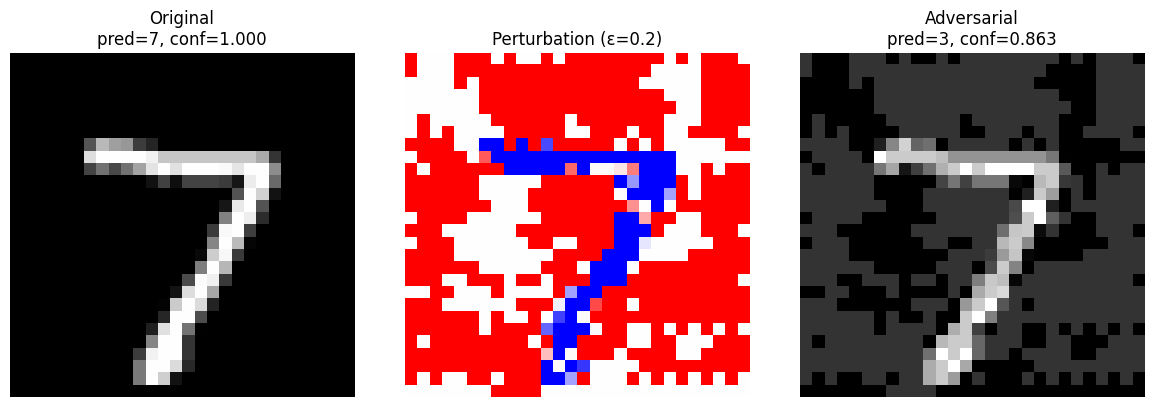

True label: 7
Clean pred: 7 (conf=1.000)
Adv   pred: 3 (conf=0.863)


In [ ]:
# TODO: выберите пример из test_loader
# TODO: примените fgsm_attack
# TODO: получите предсказания модели на оригинале и adversarial-примере (класс + confidence через softmax)
# TODO: постройте matplotlib-визуализацию из 3 подграфиков
model.eval()
x_batch, y_batch = next(iter(test_loader))
idx = 0
x0 = x_batch[idx:idx+1].to(device)
y0 = y_batch[idx:idx+1].to(device)

eps_vis = 0.2
x_adv = fgsm_attack(model, x0, y0, eps_vis, criterion)
perturbation = (x_adv - x0).detach().cpu().squeeze().numpy()

with torch.no_grad():
    p_clean = F.softmax(model(x0), dim=1).cpu().squeeze().numpy()
    p_adv = F.softmax(model(x_adv), dim=1).cpu().squeeze().numpy()

pred_clean, conf_clean = p_clean.argmax(), p_clean.max()
pred_adv, conf_adv = p_adv.argmax(),   p_adv.max()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(x0.cpu().squeeze(), cmap="gray")
axes[0].set_title(f"Original\npred={pred_clean}, conf={conf_clean:.3f}")
axes[0].axis("off")

axes[1].imshow(perturbation, cmap="bwr", vmin=-eps_vis, vmax=eps_vis)
axes[1].set_title(f"Perturbation (ε={eps_vis})")
axes[1].axis("off")

axes[2].imshow(x_adv.cpu().squeeze(), cmap="gray")
axes[2].set_title(f"Adversarial\npred={pred_adv}, conf={conf_adv:.3f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"True label: {y0.item()}")
print(f"Clean pred: {pred_clean} (conf={conf_clean:.3f})")
print(f"Adv   pred: {pred_adv} (conf={conf_adv:.3f})")

**Вопрос для отчёта:** удалось ли изменить предсказание модели? Является ли визуально заметным возмущение? Какой класс присвоила модель adversarial-примеру?

_Ваш ответ:_

Да, предсказание модели удалось изменить - с правильного класса 7 (уверенность 100%) на неправильный класс 3 (уверенность 86,3%), причём модель ошиблась уверенно. Возмущение визуально практически незаметно. Модель присвоила adversarial-примеру класс 3 с уверенностью 86,3%.

### 3.3. Attack Success Rate в зависимости от ε

**Задание:** постройте график зависимости Attack Success Rate (доли тестовых примеров, на которых атака меняет предсказание) от бюджета \(\epsilon\) для набора значений \(\epsilon \in \{0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3\}\).

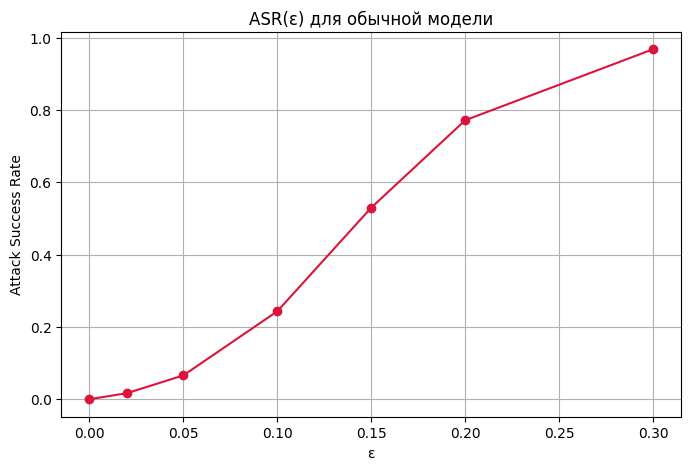

ε=0.00  ASR=0.0000
ε=0.02  ASR=0.0168
ε=0.05  ASR=0.0660
ε=0.10  ASR=0.2434
ε=0.15  ASR=0.5301
ε=0.20  ASR=0.7719
ε=0.30  ASR=0.9684


In [ ]:
# TODO: реализуйте функцию оценки ASR на подмножестве тестовой выборки
def evaluate_asr(model, loader, epsilon, criterion, n_batches=10):
    # TODO
    model.eval()
    changed, total = 0, 0
    batches_seen = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        # предсказание на чистых данных
        with torch.no_grad():
            pred_clean = model(x).argmax(1)
        # строим adversarial-пример (при eps=0 он совпадает с оригиналом)
        if epsilon > 0:
            x_adv = fgsm_attack(model, x, y, epsilon, criterion)
        else:
            x_adv = x
        # предсказание на adversarial-примере
        with torch.no_grad():
            pred_adv = model(x_adv).argmax(1)
        # считаем, сколько предсказаний изменилось
        changed += (pred_adv != pred_clean).sum().item()
        total += y.size(0)
        batches_seen += 1
        if batches_seen >= n_batches:
            break
    return changed / total

epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
# TODO: рассчитайте ASR для каждого epsilon и постройте график
asr_values = [evaluate_asr(model, test_loader, e, criterion) for e in epsilons]

plt.figure(figsize=(8, 5))
plt.plot(epsilons, asr_values, marker="o", color="crimson")
plt.xlabel("ε")
plt.ylabel("Attack Success Rate")
plt.title("ASR(ε) для обычной модели")
plt.grid(True)
plt.show()

for e, a in zip(epsilons, asr_values):
    print(f"ε={e:.2f}  ASR={a:.4f}")


**Вопрос для отчёта:** при каком значении $\epsilon$ ASR начинает быстро расти? Совместимо ли это значение с визуальной незаметностью возмущения (сравните с примером из п.3.2)?

_Ваш ответ:_

Быстрый рост ASR начинается при ε ~ 0.10–0.15. До этого атака почти не работает (ε = 0.05), но после ε = 0.10 кривая резко идёт вверх. Основной скачок на интервале от 0.10 до 0.20, где ASR вырастает примерно в 3 раза. Это значение полностью совместимо с визуальной незаметностью: в п.3.2 при ε = 0.2 adversarial-пример был неотличим от оригинала (карта возмущения выглядела контрастной лишь из-за растянутой шкалы), а при ε = 0.10–0.15 возмущение ещё слабее.

## Часть IV. Adversarial training

**Задание:** обучите вторую модель (такую же архитектуру, как MyCNN) с использованием adversarial training по формуле

$ \tilde{J}(\theta, x, y) = \alpha J(\theta, x, y) + (1-\alpha) J(\theta, x_{adv}, y) $

с $\alpha = 0.5$ и $\epsilon$, использованным при обучении, равным одному из средних значений из п.3.3.

In [ ]:
# TODO: реализуйте цикл adversarial training
# На каждом шаге:
# 1. Постройте x_adv через fgsm_attack для текущего батча
# 2. Посчитайте комбинированный loss (alpha * loss_clean + (1-alpha) * loss_adv)
# 3. Сделайте шаг оптимизации

alpha = 0.5
eps_train = 0.1   # среднее значение из п.3.3

adv_model = MyCNN().to(device)
adv_optimizer = torch.optim.Adam(adv_model.parameters(), lr=1e-3)

def train_one_epoch_adv(model, loader, optimizer, criterion, device, eps, alpha):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        # строим adversarial-пример (модель в eval для чистого градиента)
        model.eval()
        x_adv = fgsm_attack(model, x, y, eps, criterion)
        model.train()

        optimizer.zero_grad()
        logits_clean = model(x)
        logits_adv   = model(x_adv)
        loss = alpha * criterion(logits_clean, y) + (1 - alpha) * criterion(logits_adv, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits_clean.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

for epoch in range(3):
    loss, acc = train_one_epoch_adv(adv_model, train_loader, adv_optimizer,
                                    criterion, device, eps_train, alpha)
    print(f"[Adv] Epoch {epoch+1}: loss={loss:.4f}, train_acc={acc:.4f}")


[Adv] Epoch 1: loss=0.3800, train_acc=0.9259
[Adv] Epoch 2: loss=0.1285, train_acc=0.9831
[Adv] Epoch 3: loss=0.0949, train_acc=0.9886


Adv-trained clean accuracy: 0.9897


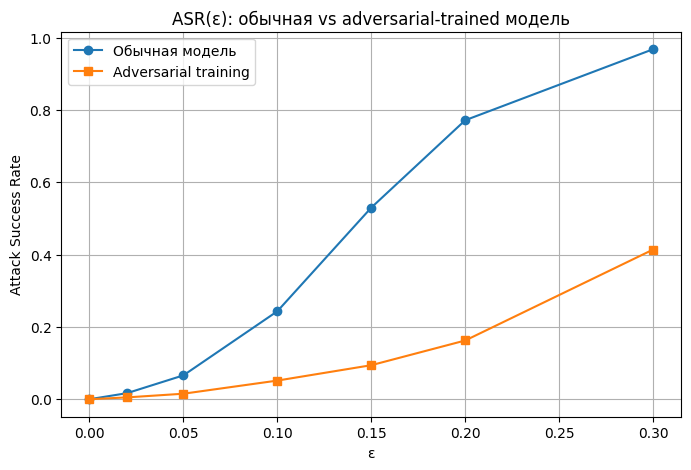

ε=0.00  ASR_clean=0.0000  ASR_adv=0.0000
ε=0.02  ASR_clean=0.0168  ASR_adv=0.0051
ε=0.05  ASR_clean=0.0660  ASR_adv=0.0152
ε=0.10  ASR_clean=0.2434  ASR_adv=0.0516
ε=0.15  ASR_clean=0.5301  ASR_adv=0.0941
ε=0.20  ASR_clean=0.7719  ASR_adv=0.1625
ε=0.30  ASR_clean=0.9684  ASR_adv=0.4141


In [ ]:
# TODO: оцените clean accuracy adversarial-trained модели
# TODO: постройте график ASR(epsilon) для adv_model и сравните с обычной моделью на одном графике
adv_clean_acc = evaluate_accuracy(adv_model, test_loader, device)
print(f"Adv-trained clean accuracy: {adv_clean_acc:.4f}")

asr_adv = [evaluate_asr(adv_model, test_loader, e, criterion) for e in epsilons]

plt.figure(figsize=(8, 5))
plt.plot(epsilons, asr_values, marker="o", label="Обычная модель")
plt.plot(epsilons, asr_adv,   marker="s", label="Adversarial training")
plt.xlabel("ε")
plt.ylabel("Attack Success Rate")
plt.title("ASR(ε): обычная vs adversarial-trained модель")
plt.grid(True)
plt.legend()
plt.show()

for e, a_clean, a_adv in zip(epsilons, asr_values, asr_adv):
    print(f"ε={e:.2f}  ASR_clean={a_clean:.4f}  ASR_adv={a_adv:.4f}")

ASR (Attack Success Rate) — это доля картинок, на которых атака сработала.Видим, что защита работает, так как процент картинок, на которых сработала ~ 41%, а на чистом наборе ~ 97% атака сработала, это практически крах.

**Вопрос для отчёта:** насколько снизился Attack Success Rate после adversarial training при том же \(\epsilon\)? Изменилась ли clean accuracy (точность на чистых данных)? Согласуется ли это с ограничением FGSM-adversarial training, упомянутым в лекции (устойчивость только к одношаговым атакам)?

_Ваш ответ:_

После adversarial training ASR упал в 3–6 раз при тех же ε (например, при ε = 0.15 с 53% до 9.4%, при ε = 0.10 с 24.3% до 5.2%). Clean accuracy практически не изменилась 0.9897 против ~ 0.990. Это согласуется с ограничением из лекции, защита максимальна в окрестности обучающего ε ~ 0.15 (разрыв 5.6 раз), но слабеет при больших ε (при 0.30 разрыв падает до 2.3 раз), то есть устойчивость формируется только к одношаговым FGSM-атакам.

## Часть V. Итоговый вывод

**Вопрос для отчёта:** сформулируйте связь между математическими свойствами CNN (высокая размерность входа, локальная связность) и существованием adversarial-примеров, опираясь на линейную гипотезу Гудфеллоу. Почему увеличение разрешения изображения потенциально увеличивает уязвимость модели к $L_\infty$-ограниченным атакам?

_Ваш ответ:_

Линейная гипотеза Гудфеллоу объясняет существование adversarial-примеров не нелинейностью сети, а высокой размерностью входа. Если модель ведёт себя как линейная функция, то при возмущении, ограниченном по максимальной амплитуде каждого пикселя, сдвиг выхода оказывается пропорционален сумме модулей всех весов. В пространстве большой размерности эта сумма растёт линейно с числом входов: чем больше пикселей, тем больше слагаемых, и даже крошечное изменение каждого из них в сумме даёт заметный сдвиг выхода. Свёрточные сети локально ведут себя почти линейно (ReLU кусочно-линейна), а их вход имеет размерность «высота × ширина × каналы». Поэтому при увеличении разрешения изображения — например, переходе от 28×28 к 224×224, то есть к в 64 раза большему числу пикселей — суммарный вклад всех весов эффективно растёт, и при фиксированном ε сдвиг логитов увеличивается пропорционально размерности. Это делает модели компьютерного зрения тем более уязвимыми к атакам с ограничением по максимальной амплитуде возмущения, чем выше разрешение входа, что и подтверждается эмпирически.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже .

### С1. Влияние глубины архитектуры на устойчивость к FGSM
Обучите две версии MyCNN с разной глубиной (например, 2 и 5 свёрточных слоёв, при сопоставимом числе параметров) и сравните их ASR(ε). Свяжите результат с обсуждением иерархии признаков и рецептивного поля из лекции.

### С2. Целевая (targeted) FGSM-атака
Модифицируйте FGSM так, чтобы атака заставляла модель предсказывать конкретный целевой класс (а не просто любой неверный), минимизируя loss по целевому классу вместо максимизации loss по истинному. Сравните Success Rate целевой и нецелевой атаки при одинаковом ε.

### С3. Трансферируемость adversarial-примеров
Обучите две модели с разной архитектурой (например, разное число слоёв/каналов). Постройте adversarial-примеры для модели А методом FGSM и проверьте, насколько успешно они обманывают необученную на этих примерах модель Б. Свяжите результат со свойством трансферируемости, разобранным в лекции (Szegedy et al.).

### С4. Аналитическая иллюстрация линейной гипотезы
Реализуйте эксперимент из демонстрационного ноутбука (раздел «линейная гипотеза») самостоятельно: постройте график зависимости среднего сдвига выхода линейной модели \( w^T\eta^* = \epsilon\|w\|_1 \) от размерности входа \(n\) для нескольких значений \(\epsilon\) на одном графике. Объясните, почему это объясняет уязвимость моделей компьютерного зрения именно с ростом разрешения изображений.


Shallow params: 421,642
Deep params:    110,010
Training ShallowCNN...
  epoch 1: loss=0.2291, acc=0.9303
  epoch 2: loss=0.0573, acc=0.9822
  epoch 3: loss=0.0388, acc=0.9877
Training DeepCNN...
  epoch 1: loss=0.3249, acc=0.8922
  epoch 2: loss=0.0668, acc=0.9792
  epoch 3: loss=0.0442, acc=0.9862
Shallow clean acc: 0.9846
Deep    clean acc: 0.9873


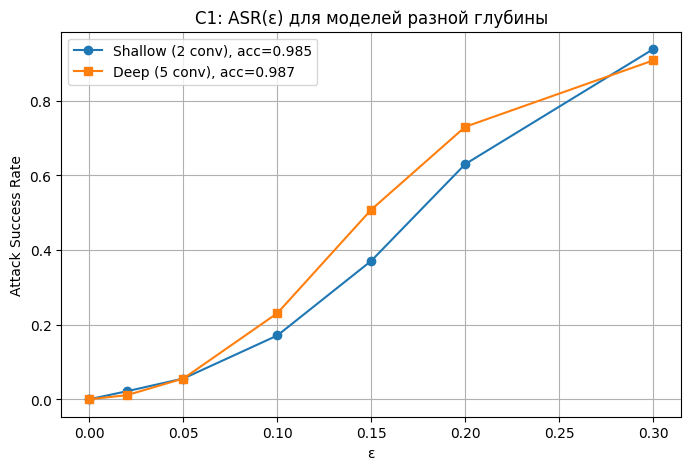

In [ ]:
# TODO: реализуйте выбранные задания (С1-С4) здесь
# С1 (Влияние глубины архитектуры на устойчивость к FGSM)
class ShallowCNN(nn.Module):
    # 2 свёрточных слоя
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


class DeepCNN(nn.Module):
    #5 свёрточных слоёв с уменьшенным числом каналов
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 16, 3, padding=1)
        self.conv3 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv4 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv5 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))   # 28
        x = self.pool(F.relu(self.conv2(x)))  # 14
        x = F.relu(self.conv3(x))   # 14
        x = self.pool(F.relu(self.conv4(x)))  # 7
        x = self.pool(F.relu(self.conv5(x)))  # 3
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

shallow = ShallowCNN().to(device)
deep = DeepCNN().to(device)
print(f"Shallow params: {count_params(shallow):,}")
print(f"Deep params:    {count_params(deep):,}")

def train_model(m, epochs=3, lr=1e-3):
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    for ep in range(epochs):
        loss, acc = train_one_epoch(m, train_loader, opt, criterion, device)
        print(f"  epoch {ep+1}: loss={loss:.4f}, acc={acc:.4f}")
    return m

print("Training ShallowCNN...")
train_model(shallow)
print("Training DeepCNN...")
train_model(deep)

acc_shallow = evaluate_accuracy(shallow, test_loader, device)
acc_deep    = evaluate_accuracy(deep, test_loader, device)
print(f"Shallow clean acc: {acc_shallow:.4f}")
print(f"Deep    clean acc: {acc_deep:.4f}")

asr_shallow = [evaluate_asr(shallow, test_loader, e, criterion) for e in epsilons]
asr_deep    = [evaluate_asr(deep,    test_loader, e, criterion) for e in epsilons]

plt.figure(figsize=(8, 5))
plt.plot(epsilons, asr_shallow, marker="o", label=f"Shallow (2 conv), acc={acc_shallow:.3f}")
plt.plot(epsilons, asr_deep,    marker="s", label=f"Deep (5 conv), acc={acc_deep:.3f}")
plt.xlabel("ε")
plt.ylabel("Attack Success Rate")
plt.title("С1: ASR(ε) для моделей разной глубины")
plt.grid(True)
plt.legend()
plt.show()

Глубокая сеть (5 свёрток, 110 тысяч параметров) дала чуть лучшую clean accuracy, чем shallow (0.9873 против 0.9846), но оказалась более уязвимой к FGSM - её ASR выше при средних ε (0.15: 0.51 против 0.37). Это согласуется с ростом рецептивного поля: чем глубже сеть, тем на большее число нейронов влияет одно возмущение. При больших ε (0.30) обе модели сближаются.

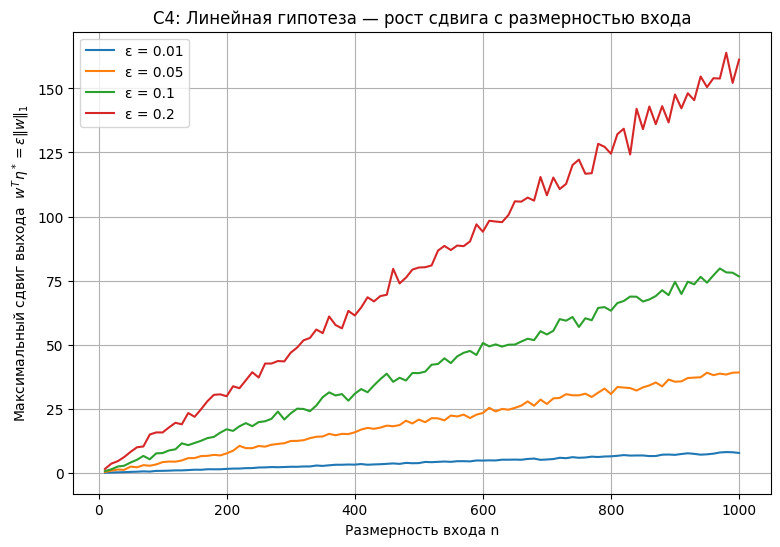

E[|w_i|] = 0.7978845608028654
Теоретический наклон при ε=0.1: 0.07978845608028655


In [ ]:
# С4(Аналитическая иллюстрация линейной гипотезы)
np.random.seed(RANDOM_STATE)

dims = np.arange(10, 1001, 10)
eps_list = [0.01, 0.05, 0.1, 0.2]

plt.figure(figsize=(9, 6))
for eps in eps_list:
    shifts = []
    for n in dims:
        w = np.random.normal(0, 1, size=n)   #веса
        shifts.append(eps * np.sum(np.abs(w)))
    plt.plot(dims, shifts, label=f"ε = {eps}")

plt.xlabel("Размерность входа n")
plt.ylabel(r"Максимальный сдвиг выхода  $w^T\eta^* = \epsilon\|w\|_1$")
plt.title("С4: Линейная гипотеза — рост сдвига с размерностью входа")
plt.grid(True)
plt.legend()
plt.show()

# Теоретическая оценка
print("E[|w_i|] =", np.sqrt(2 / np.pi))
print("Теоретический наклон при ε=0.1:", 0.1 * np.sqrt(2 / np.pi))

График подтверждает линейную гипотезу: сдвиг выхода растёт линейно с размерностью входа — все линии почти прямые, а наклон пропорционален ε. Эмпирическая оценка среднего модуля веса (0.798) совпала с теоретической (0.798), а наклон при ε = 0.1 (0.0798) точно совпал с предсказанием теории. Это значит: при одном и том же ε сдвиг выхода тем больше, чем больше пикселей на входе. Для ImageNet (~ 150 000 пикселей) сдвиг будет примерно в 200 раз сильнее, чем для MNIST (~ 784 пикселя). Поэтому рост разрешения увеличивает уязвимость модели к атакам с ограничением по максимальной амплитуде возмущения.

---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны: расчёт RF, реализация FGSM, график ASR(ε), сравнение с adversarial training.
